In [1]:
import os

import kinase_library as kl

import pandas as pd



In [2]:
bdnf_1_hr = pd.read_csv('/Users/annaleigh/Documents/GitHub/lmn_bdnf/data/phospho_bdnf_1hr_for_enrichment_psp_version2.tsv', sep='\t')
bdnf_1_hr

,gene_names,phospho_position,uniprot_flank_larger,remapped_amino,needs_padding,padding,phospho_sty_probabilities,log_fc,p_value
0,YBX3,102,NPRKYLRSVGDGETV,S,no,NaN,S(0.713)VGDGET(0.287)VEFDVVEGEK,3.359553e+00,1.969195e-07
1,YBX1,102,NPRKYLRSVGDGETV,S,no,NaN,S(0.713)VGDGET(0.287)VEFDVVEGEK,3.359553e+00,1.969195e-07
2,YBX2,102,NPRKYLRSVGDGETV,S,no,NaN,S(0.713)VGDGET(0.287)VEFDVVEGEK,3.359553e+00,1.969195e-07
3,TSC2,1798,GQRKRLISSVEDFTE,S,no,NaN,LIS(0.5)S(0.5)VEDFTEFV,3.333986e+00,7.574926e-07
4,TSC2,1799,QRKRLISSVEDFTEF,S,no,NaN,LIS(0.5)S(0.5)VEDFTEFV,3.333986e+00,7.574926e-07
...,...,...,...,...,...,...,...,...,...
5948,MDN1,4754,EDDEKSDSEGGDLDK,S,no,NaN,MHDGELEEQEEDDEKS(0.5)DS(0.5)EGGDLDK,-7.685263e-05,9.997852e-01
5949,IGSF9B,845,EAEAEATTPIELISR,T,no,NaN,AEAEAEAT(0.013)T(0.987)PIELISR,-6.630900e-05,9.998131e-01
5950,GSK3A,216,RGEPNVSYICSRYYR,Y,no,NaN,GEPNVS(0.113)Y(0.887)ICSR,-4.664702e-05,9.997551e-01
5951,GSK3B,216,RGEPNVSYICSRYYR,Y,no,NaN,GEPNVS(0.113)Y(0.887)ICSR,-4.664702e-05,9.997551e-01


In [3]:
bdnf_1_hr_diff = kl.DiffPhosData(bdnf_1_hr, lfc_col='log_fc', pval_col='p_value', seq_col='uniprot_flank_larger', pval_thresh=0.1, suppress_warnings=True)


In [4]:
kin_type = 'ser_thr'
method = 'percentile_rank'
thresh = 15

bdnf_1_hr_diff_res = bdnf_1_hr_diff.kinase_enrichment(kin_type=kin_type, kl_method=method, kl_thresh=thresh)


Calculating percentiles for upregulated sites (554 substrates)
Scoring 550 ser_thr substrates
Calculating percentile for 550 ser_thr substrates
100%|██████████| 311/311 [00:02<00:00, 151.38it/s] 
                                                  

Calculating percentiles for downregulated sites (463 substrates)
Scoring 453 ser_thr substrates
Calculating percentile for 453 ser_thr substrates
100%|██████████| 311/311 [00:01<00:00, 184.75it/s] 
                                                  

Calculating percentiles for background (unregulated) sites (4936 substrates)
Scoring 4879 ser_thr substrates
Calculating percentile for 4879 ser_thr substrates
100%|██████████| 311/311 [00:02<00:00, 151.73it/s] 
                                                  


In [5]:
bdnf_1_hr_diff_res.combined_enrichment_results
bdnf_1_hr_diff_res.combined_enrichment_results.to_csv("/Users/annaleigh/Documents/GitHub/lmn_bdnf/data/kinase_library_prediction_1hr.csv")


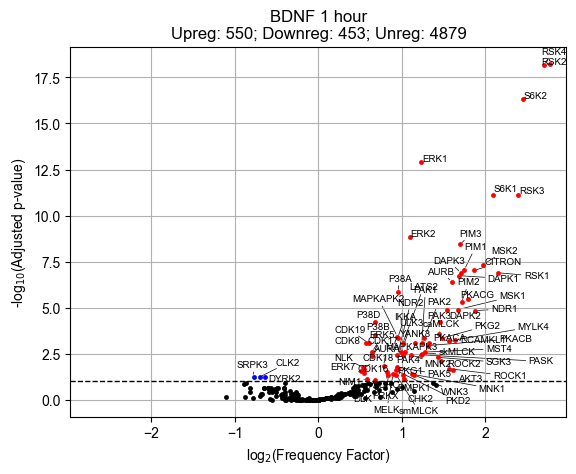

In [6]:
bdnf_1_hr_diff_res.plot_volcano(title='BDNF 1 hour')


In [14]:
kl.Kinome().generate_tree("output/enrichment_tree1hr.svg",
                          bdnf_1_hr_diff_res.combined_enrichment_results, filter_top=50, 
                          coloring_column="most_sig_log2_freq_factor",branch_color = "#000000",
                          thresholds={ "high": 2.0, "middle": 0.0, "low": -0.2 })


Calculating percentiles for upregulated sites (567 substrates)
Scoring 556 ser_thr substrates
Calculating percentile for 556 ser_thr substrates
100%|██████████| 311/311 [00:01<00:00, 173.85it/s] 
                                                  

Calculating percentiles for downregulated sites (570 substrates)
Scoring 560 ser_thr substrates
Calculating percentile for 560 ser_thr substrates
100%|██████████| 311/311 [00:01<00:00, 189.14it/s] 
                                                  

Calculating percentiles for background (unregulated) sites (4816 substrates)
Scoring 4766 ser_thr substrates
Calculating percentile for 4766 ser_thr substrates
100%|██████████| 311/311 [00:01<00:00, 165.95it/s] 
                                                  


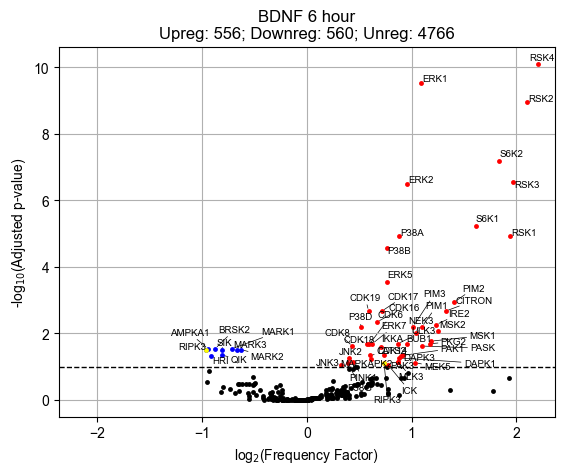

In [15]:
bdnf_6_hr = pd.read_csv('/Users/annaleigh/Documents/GitHub/lmn_bdnf/data/phospho_bdnf_6hr_for_enrichment_psp_version2.tsv', sep='\t')
bdnf_6_hr_diff = kl.DiffPhosData(bdnf_6_hr, lfc_col='log_fc', pval_col='p_value', seq_col='uniprot_flank_larger', pval_thresh=0.1, suppress_warnings=True)
kin_type = 'ser_thr'
method = 'percentile_rank'
thresh = 15

bdnf_6_hr_diff_res = bdnf_6_hr_diff.kinase_enrichment(kin_type=kin_type, kl_method=method, kl_thresh=thresh)
bdnf_6_hr_diff_res.plot_volcano(title='BDNF 6 hour')
bdnf_6_hr_diff_res.combined_enrichment_results.to_csv("/Users/annaleigh/Documents/GitHub/lmn_bdnf/data/kinase_library_prediction_6hr.csv")
kl.Kinome().generate_tree("output/enrichment_tree6hr.svg",
                          bdnf_6_hr_diff_res.combined_enrichment_results, filter_top=50, 
                          coloring_column="most_sig_log2_freq_factor",branch_color = "#000000",
                          thresholds={ "high": 2.0, "middle": 0.0, "low": -0.2 })